# HistGBM — Simplified Feature Set

**Features:** `subject_age` (median-imputed), `subject_sex`, `grouped_vio`, `community_area_name`  
**Outcome:** `citation_issued` (1 = cited, 0 = not cited)

> **Note:** Run this notebook from the directory containing `traffic_analysis_grouped_vio.csv`.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_validate, train_test_split, GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

SEED = 42
FIGS = Path("figures")
FIGS.mkdir(exist_ok=True)

## 1. Load Data

In [8]:
df = pd.read_csv("traffic_analysis_grouped_vio.csv", low_memory=False)

df["citation"] = df["citation_issued"].map(
    {True: 1, False: 0, "True": 1, "False": 0}
).fillna(0).astype(int)

## 2. Feature Preparation

In [9]:
FEATURES = ["subject_sex", "grouped_vio", "community_area_name"]
CAT_FEATS = ["subject_sex", "grouped_vio", "community_area_name"]

df_model = df[FEATURES + ["citation"]].copy()

# Drop rows missing sex or community (very few)
df_model = df_model.dropna(subset=["subject_sex", "community_area_name"])

print(f"Modeling rows: {len(df_model):,}")
print(f"Citation rate: {df_model['citation'].mean():.2%}")
print(f"Community areas: {df_model['community_area_name'].nunique()}")
print(f"Violation groups: {df_model['grouped_vio'].nunique()}")

# Save community areas for group-based split (before encoding)
groups = df_model["community_area_name"].copy()

# Encode categoricals
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_model[CAT_FEATS] = enc.fit_transform(df_model[CAT_FEATS])

X = df_model[FEATURES]
y = df_model["citation"]

Modeling rows: 1,876,610
Citation rate: 31.82%
Community areas: 76
Violation groups: 9


## 3. Model — HistGBM

Same hyperparameters as `analysis.py` model D. Uses 5-fold group-based cross-validation, grouped by `community_area_name`, to prevent data leakage across geographic areas.

In [10]:
clf = HistGradientBoostingClassifier(
    max_iter=400,
    max_depth=6,
    learning_rate=0.05,
    min_samples_leaf=40,
    random_state=SEED,
    class_weight="balanced",
)

CV = GroupKFold(n_splits=5)
SCORING = ["roc_auc", "average_precision", "f1"]

print("Running 5-fold group-based cross-validation...")
cv_results = cross_validate(clf, X, y, cv=CV, groups=groups, scoring=SCORING,
                            return_train_score=False, n_jobs=-1)

roc = cv_results["test_roc_auc"]
ap  = cv_results["test_average_precision"]
f1  = cv_results["test_f1"]

print(f"\n5-Fold Group CV Results:")
print(f"  ROC-AUC:       {roc.mean():.3f} +/- {roc.std():.3f}")
print(f"  Avg Precision: {ap.mean():.3f} +/- {ap.std():.3f}")
print(f"  F1:            {f1.mean():.3f} +/- {f1.std():.3f}")

Running 5-fold group-based cross-validation...

5-Fold Group CV Results:
  ROC-AUC:       0.600 +/- 0.132
  Avg Precision: 0.413 +/- 0.078
  F1:            0.503 +/- 0.081


## 4. ROC & Precision-Recall Curves

Single 80/20 group-stratified split for visualization.

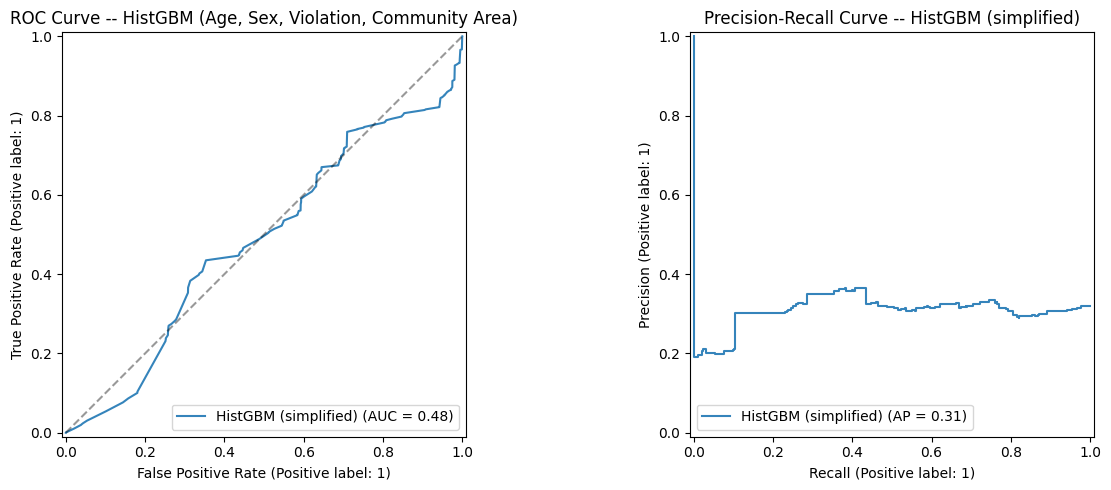

Curves saved to figures/histgbm_simplified_curves.png


In [11]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
clf.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_estimator(clf, X_te, y_te, ax=axes[0],
                               name="HistGBM (simplified)", alpha=0.9)
axes[0].plot([0,1],[0,1],"k--",alpha=0.4)
axes[0].set_title("ROC Curve -- HistGBM (Age, Sex, Violation, Community Area)")

PrecisionRecallDisplay.from_estimator(clf, X_te, y_te, ax=axes[1],
                                      name="HistGBM (simplified)", alpha=0.9)
axes[1].set_title("Precision-Recall Curve -- HistGBM (simplified)")

plt.tight_layout()
out_path = FIGS / "histgbm_simplified_curves.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Curves saved to {out_path}")